In [33]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("OpenCV Version:", cv2.__version__)

# Define paths pointing to the folders in your left sidebar
TRAIN_DIR = "Training"
TEST_DIR = "Testing"

if os.path.exists(TRAIN_DIR):
    print("Successfully connected! Training folders found:", os.listdir(TRAIN_DIR))
else:
    print("Error: Cannot find the Training folder. Check your folder structure.")


TensorFlow Version: 2.21.0
OpenCV Version: 5.0.0
Successfully connected! Training folders found: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [34]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

CATEGORIES = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
IMG_SIZE = 128  # Resize all MRIs to 128x128 pixels

def load_data(dir_path):
    X = [] # Holds the images
    y = [] # Holds the labels (0, 1, 2, or 3)
    
    for category in CATEGORIES:
        path = os.path.join(dir_path, category)
        class_num = CATEGORIES.index(category) # Converts names to numbers
        
        if not os.path.exists(path):
            continue
            
        for img in os.listdir(path):
            try:
                # Read image in grayscale since MRIs don't need color
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
                resized_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                X.append(resized_array)
                y.append(class_num)
            except Exception as e:
                pass # Skip any corrupted images
                
    return np.array(X), np.array(y)

# Load everything from your Training folder
print("Loading images... Please wait...")
X_raw, y_raw = load_data("Training")

# Normalize data (Scale pixel values between 0 and 1)
X_raw = X_raw.astype('float32') / 255.0
# Add a channel dimension for grayscale (required by CNN layers)
X_raw = np.expand_dims(X_raw, axis=-1)

# Split your data into training (80%) and validation (20%) sets
X_train, X_val, y_train, y_val = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)

print(f"Total Training Images Loaded: {len(X_train)}")
print(f"Total Validation Images Loaded: {len(X_val)}")
print(f"Image Shape: {X_train[0].shape}")


Loading images... Please wait...
Total Training Images Loaded: 2296
Total Validation Images Loaded: 574
Image Shape: (128, 128, 1)


In [76]:
# Train the model using your data variables
history = model.fit(
    X_train, y_train,
    epochs=15,               # Number of complete passes over the dataset
    batch_size=32,           # Train on 32 images at a time
    validation_data=(X_val, y_val) # Test against validation set after every cycle
)


Epoch 1/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 9s 117ms/step - accuracy: 0.5414 - loss: 1.0465 - val_accuracy: 0.6202 - val_loss: 0.8357
Epoch 2/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 9s 120ms/step - accuracy: 0.7099 - loss: 0.7002 - val_accuracy: 0.7613 - val_loss: 0.6250
Epoch 3/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 9s 121ms/step - accuracy: 0.7888 - loss: 0.5220 - val_accuracy: 0.7648 - val_loss: 0.5191
Epoch 4/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 9s 121ms/step - accuracy: 0.8371 - loss: 0.4113 - val_accuracy: 0.8328 - val_loss: 0.4307
Epoch 5/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 9s 130ms/step - accuracy: 0.8759 - loss: 0.3240 - val_accuracy: 0.8328 - val_loss: 0.4514
Epoch 6/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 12s 162ms/step - accuracy: 0.9085 - loss: 0.2423 - val_accuracy: 0.8571 - val_loss: 0.3799
Epoch 7/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 15s 208ms/step - accuracy: 0.9229 - loss: 0.2056 - val_accuracy: 0.8554 - val_loss: 0.3875
Epoch 8/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 18s 256ms/step - accuracy: 0.9316 - loss: 0.1743 - val_accuracy:

In [75]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Compiling your original highly successful custom layout structure
model = models.Sequential([
    # First Conv Block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 1)),
    layers.MaxPooling2D((2, 2)),
    
    # Second Conv Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Third Conv Block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Dense reasoning layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), 
    layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  
    metrics=['accuracy']
)

model.summary()


c:\Users\mohit\miniconda3\envs\myenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_36 (Conv2D)              │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,580 (12.61 MB)

 Trainable params: 3,304,580 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

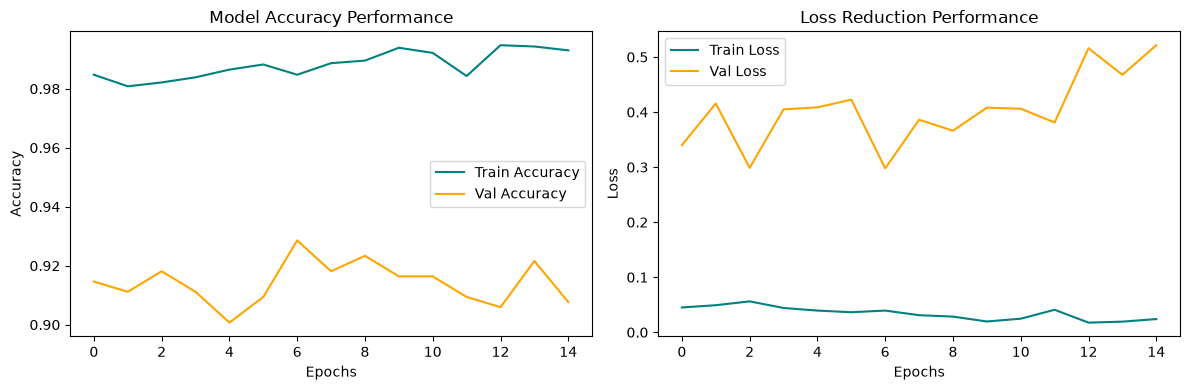

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step

--- DETAILED DIAGNOSTIC REPORT ---
                  precision    recall  f1-score   support

    glioma_tumor       0.33      0.98      0.49       179
meningioma_tumor       0.00      0.00      0.00       169
        no_tumor       0.00      0.00      0.00        70
 pituitary_tumor       0.18      0.04      0.06       156

        accuracy                           0.32       574
       macro avg       0.13      0.26      0.14       574
    weighted avg       0.15      0.32      0.17       574



c:\Users\mohit\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mohit\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mohit\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

In [73]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Plot Training vs Validation Accuracy over cycles
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='teal')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('Model Accuracy Performance')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# 2. Plot Training vs Validation Loss reduction
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='teal')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Loss Reduction Performance')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# 3. Generate a Classification Precision Report
# Make predictions on the validation set
predictions = model.predict(X_val)
predicted_classes = np.argmax(predictions, axis=1)

print("\n--- DETAILED DIAGNOSTIC REPORT ---")
print(classification_report(y_val, predicted_classes, target_names=CATEGORIES))


In [77]:
model.save("brain_tumor_cnn_model.keras")
print("High-performance weights successfully locked in!")


High-performance weights successfully locked in!


In [17]:
%pip install seaborn tensorflow scikit-learn matplotlib


Note: you may need to restart the kernel to use updated packages.


In [78]:
model.save("brain_tumor_cnn_model.keras")
print("High-performance weights successfully locked onto hard drive!")


High-performance weights successfully locked onto hard drive!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


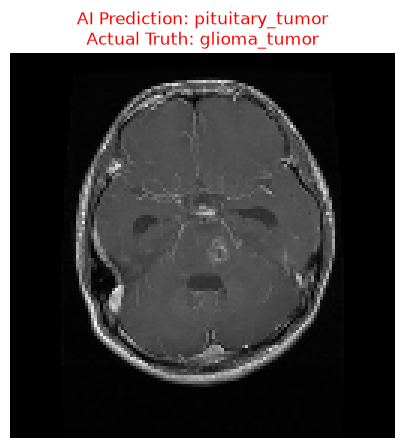

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# Grab the very first image from your validation pool
test_image = X_val[0] 
true_label_index = y_val[0]

# Preprocess it for the model (add batch dimension)
input_image = np.expand_dims(test_image, axis=0)

# Make the prediction
raw_prediction = model.predict(input_image)
predicted_label_index = np.argmax(raw_prediction)

# Map numeric labels back to their text names
CATEGORIES = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
predicted_diagnosis = CATEGORIES[predicted_label_index]
actual_diagnosis = CATEGORIES[true_label_index]

# Display the MRI scan with the model's conclusion
plt.figure(figsize=(5,5))
plt.imshow(test_image.squeeze(), cmap='gray') # squeeze removes channel dimension for plotting
plt.title(f"AI Prediction: {predicted_diagnosis}\nActual Truth: {actual_diagnosis}", 
          color='green' if predicted_diagnosis == actual_diagnosis else 'red')
plt.axis('off')
plt.show()


In [20]:
!pip install streamlit




In [79]:
import os
import cv2
import numpy as np
import tensorflow as tf

# 1. Load your saved high-performance model
print("Loading trained model weights...")
model = tf.keras.models.load_model("brain_tumor_cnn_model.keras")

# 2. Define the rigid index order established during your training phase
# 0 = glioma_tumor, 1 = meningioma_tumor, 2 = no_tumor, 3 = pituitary_tumor
CATEGORIES = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
IMG_SIZE = 128
TEST_DIR = "Testing"

X_test = []
y_test = []

print("Loading test images in strict alphabetical label mapping sequence...")

# 3. Use the rigid training category list to scan your directory folders systematically
for category in CATEGORIES:
    # Look inside 'Testing/glioma_tumor', then 'Testing/meningioma_tumor', etc.
    path = os.path.join(TEST_DIR, category)
    class_num = CATEGORIES.index(category) # Forces the index to perfectly match training
    
    if not os.path.exists(path):
        print(f"Warning: Folder '{path}' not found. Checking for alternative naming standard...")
        # Fallback helper: removes '_tumor' if your Testing folders are just named 'glioma', etc.
        alt_path = os.path.join(TEST_DIR, category.replace('_tumor', ''))
        if os.path.exists(alt_path):
            path = alt_path
        else:
            print(f"Error: Unable to locate image directory for {category}!")
            continue
            
    # Process images inside the verified folder
    for img in os.listdir(path):
        try:
            img_path = os.path.join(path, img)
            img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            resized_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
            X_test.append(resized_array)
            y_test.append(class_num) # Append the correct matched index
        except:
            pass

# 4. Convert arrays to proper formats for evaluation
X_test = np.array(X_test).astype('float32') / 255.0
X_test = np.expand_dims(X_test, axis=-1)
y_test = np.array(y_test)

# 5. Execute accurate system test calculation
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

print("\n================ FINAL RE-ALIGNED RESULTS ================")
print(f"Total Completely Unseen Images Tested: {len(X_test)}")
print(f"True Model Test Accuracy: {test_accuracy * 100:.2f}%")
print("==========================================================")


Loading trained model weights...
Loading test images in strict alphabetical label mapping sequence...
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7157 - loss: 4.2875

================ FINAL RE-ALIGNED RESULTS ================
Total Completely Unseen Images Tested: 394
True Model Test Accuracy: 71.57%
